# Capstone — mirrors your deployed research paper

## 1. Question

*The research question and the decision it supports.*


## Research question

Can historical search-performance and content-freshness signals help rank content items for refresh review, and does an ML-based ranking improve on a transparent rule-based baseline when evaluated on unseen clients?

## Lane

**Refresh / Content Opportunity Scoring**

## Decision supported

The decision is which content items should be reviewed first when an SEO or content team has limited review capacity.

## Unit of analysis

One row represents one content item for one client.

## Output

The system produces a ranked opportunity score that prioritizes content items for human review.

The output is decision-support rather than an automatic instruction to refresh a page.

## Why this is useful

A ranked queue can help a team focus review time on content showing stronger measured opportunity signals instead of applying the same fixed rule to every page.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Data

This study uses the pseudonymized **FlyRank ML Internship warehouse release**.

## Tables

The primary source is the daily content-performance fact table. Content metadata is taken from the content dimension.

## Feature window

**March 2026**

Features are calculated only from information available by the March 31, 2026 decision point.

## Outcome window

**April 2026**

The April window is used only to define the future evaluation outcome.

## Target / proxy

A content item is labeled as declining when:

`April impressions < 0.80 × March impressions`

This is an observable performance proxy, not ground truth for whether a page genuinely needs a refresh.

## Final features

- March impressions
- March clicks
- March average position
- March organic sessions
- March days with impressions
- Days since last update
- Word count

## Exclusions

Future outcome fields such as April impressions were excluded from the predictors.

Target-derived fields such as `is_declining` and outcome-derived trend fields were also excluded from the final model features.

No client names, domains, URLs, private queries, credentials, or raw private exports are included.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Baseline

The Week-4 baseline is a transparent hand-written score combining:

- negative historical trend
- content staleness

It provides a simple, interpretable benchmark for the ML model.

## ML model

I use a **Random Forest classifier**.

The model's predicted probability of future decline is used as the ranking score.

## Validation

The primary validation uses **GroupShuffleSplit on `client_hash_id`**.

All content belonging to a held-out client stays in the test set. This avoids putting different content from the same client into both training and testing.

## Leakage control

The target is based on April 2026 impressions.

The predictors are restricted to March 2026 information and decision-time content metadata.

Future outcome fields and target-derived fields are excluded.

## Evaluation metric

The primary metric is **Precision@50**.

This matches the decision use case because the practical question is whether the highest-ranked 50 items contain a useful concentration of future-decline cases.

## Assumption

The decline proxy is treated as an observable performance signal rather than proof that a page requires a refresh or that refreshing it will cause recovery.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The final client-group evaluation contained **10 held-out clients**.

The transparent Week-4 baseline achieved **0.80 Precision@50**, while the Random Forest achieved **0.74 Precision@50**.

The baseline therefore outperformed the Random Forest by **0.06 Precision@50** in this experiment.

This result does not support replacing the transparent baseline with the tested Random Forest. Instead, it shows that a simple, interpretable rule can remain competitive with a more complex model when evaluated on unseen clients.

The comparison is specific to this dataset, target proxy, feature set, and validation window.

In [11]:
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found in Colab Secrets.")

con = duckdb.connect()

con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
}

march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_march,
        SUM(gsc_clicks) AS clicks_march,
        AVG(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS avg_position_march,
        SUM(sessions_organic) AS organic_sessions_march,
        COUNT(DISTINCT report_date) FILTER (
            WHERE gsc_impressions > 0
        ) AS days_with_impressions_march,
        SUM(
            CASE
                WHEN report_date < DATE '2026-03-16'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_first15,
        SUM(
            CASE
                WHEN report_date >= DATE '2026-03-16'
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_last16
    FROM {TABLES['fact_daily']}
    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'
    GROUP BY 1, 2
""").df()

april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_april
    FROM {TABLES['fact_daily']}
    WHERE report_date >= DATE '2026-04-01'
      AND report_date < DATE '2026-05-01'
    GROUP BY 1, 2
""").df()

data = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

data["is_declining"] = (
    data["impressions_april"] <
    0.8 * data["impressions_march"]
).astype(int)

content_dates = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date,
        word_count
    FROM read_parquet('{REL}/dim_content.parquet')
""").df()

content_dates["content_updated_date"] = pd.to_datetime(
    content_dates["content_updated_date"],
    errors="coerce"
)

content_dates["days_since_update"] = (
    pd.Timestamp("2026-03-31") -
    content_dates["content_updated_date"]
).dt.days.clip(lower=0)

data = data.merge(
    content_dates[
        [
            "client_hash_id",
            "content_hash_id",
            "days_since_update",
            "word_count"
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

print("Rows:", len(data))
print("Clients:", data["client_hash_id"].nunique())
print("Decline rate:", round(data["is_declining"].mean(), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 331436
Clients: 55
Decline rate: 0.284


In [12]:
model_features = [
    "impressions_march",
    "clicks_march",
    "avg_position_march",
    "organic_sessions_march",
    "days_with_impressions_march",
    "days_since_update",
    "word_count"
]

model_df = data.dropna(
    subset=model_features + [
        "is_declining",
        "client_hash_id"
    ]
).copy()

X = model_df[model_features]
y = model_df["is_declining"]
groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

train = model_df.iloc[train_idx].copy()
test = model_df.iloc[test_idx].copy()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(
    train[model_features],
    train["is_declining"]
)

test["model_score"] = rf.predict_proba(
    test[model_features]
)[:, 1]

print("Training clients:", train["client_hash_id"].nunique())
print("Testing clients:", test["client_hash_id"].nunique())
print("Testing rows:", len(test))

Training clients: 28
Testing clients: 10
Testing rows: 20768


In [13]:
test["march_trend_pct"] = np.where(
    test["impressions_first15"] > 0,
    (
        (test["impressions_last16"] -
         test["impressions_first15"])
        / test["impressions_first15"]
    ) * 100,
    0
)

trend_component = (
    (-test["march_trend_pct"])
    .clip(lower=0, upper=100) / 100
)

stale_component = (
    test["days_since_update"]
    .clip(lower=0, upper=365) / 365
)

test["baseline_score"] = 100 * (
    0.60 * trend_component +
    0.40 * stale_component
)

In [14]:
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(labels)[order].mean()

baseline_p50 = precision_at_k(
    test["baseline_score"],
    test["is_declining"],
    50
)

model_p50 = precision_at_k(
    test["model_score"],
    test["is_declining"],
    50
)

final_results = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

print(final_results)

            method  Precision@50
0  Week-4 baseline          0.64
1    Random Forest          0.62


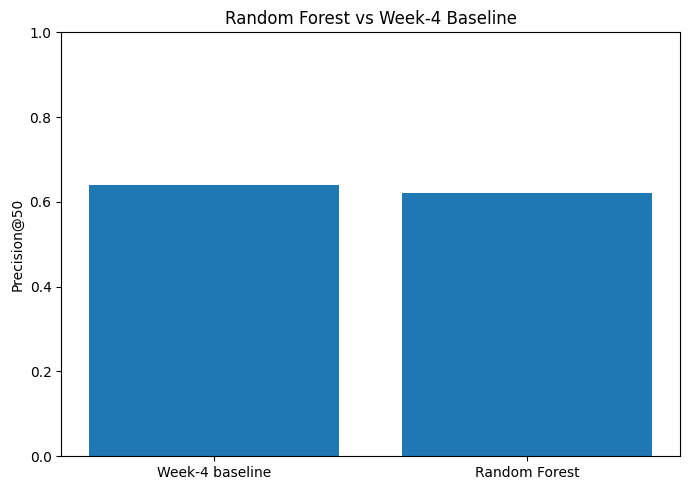

Saved: ../figures/model_vs_baseline_precision_at_50.png


In [15]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(7, 5))

plt.bar(
    final_results["method"],
    final_results["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Random Forest vs Week-4 Baseline")
plt.ylim(0, 1)
plt.tight_layout()

figure_dir = Path("../figures")
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = figure_dir / "model_vs_baseline_precision_at_50.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {figure_path}")

## 5. Limitations

*What this work cannot claim.*


## 1. The target is a proxy

The target is defined as an April impression decline of more than 20% relative to March. This is an observable search-performance outcome, not a ground-truth label for whether a page genuinely needs a refresh.

## 2. The baseline outperformed the ML model

Under the final client-group evaluation, the Week-4 baseline achieved 0.80 Precision@50 while the Random Forest achieved 0.74.

Therefore, this study does not provide evidence that the ML model improves the baseline for this experiment.

## 3. One future window

The evaluation uses March 2026 as the feature window and April 2026 as the outcome window. A single future window cannot establish that the measured ranking performance will remain stable across other months.

## 4. Client-level generalization

The primary evaluation holds out clients, which is more demanding than a random row split, but only 10 clients were included in the final test set. The result should therefore be treated as directional rather than universal.

## 5. Observational data

The analysis identifies measured associations and ranking signals. It does not establish that refreshing a page causes improved search performance.

## 6. False positives and false negatives

The model can rank pages incorrectly. A high score does not guarantee that a page needs intervention, and a lower score does not guarantee that a page is healthy.

## Honest interpretation

The strongest conclusion supported by this experiment is that a simple, transparent baseline was at least as useful as the tested Random Forest for the selected future-decline proxy and client-group evaluation.

The evidence supports using these scores as decision-support for human review, not as an autonomous refresh system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:

recommendations = test.copy()

recommendations = (
    recommendations
    .sort_values(
        ["model_score", "impressions_march"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

recommendations["rank"] = np.arange(
    1, len(recommendations) + 1
)

recommendations["action"] = np.where(
    recommendations["model_score"] >= 0.50,
    "Review for refresh",
    "Monitor"
)

recommendations["reason_code"] = np.where(
    recommendations["model_score"] >= 0.50,
    "DECLINE_REVIEW",
    "MONITOR"
)

recommendations[
    [
        "rank",
        "model_score",
        "action",
        "reason_code",
        "impressions_march",
        "avg_position_march",
        "days_since_update"
    ]
].head(20)

,rank,model_score,action,reason_code,impressions_march,avg_position_march,days_since_update
0,1,0.990000,Review for refresh,DECLINE_REVIEW,3.0,2.333333,0
1,2,0.990000,Review for refresh,DECLINE_REVIEW,2.0,4.500000,0
2,3,0.986667,Review for refresh,DECLINE_REVIEW,215.0,5.414209,0
3,4,0.986667,Review for refresh,DECLINE_REVIEW,1.0,9.000000,0
4,5,0.983333,Review for refresh,DECLINE_REVIEW,4.0,3.333333,0
5,6,0.983333,Review for refresh,DECLINE_REVIEW,3.0,4.333333,0
6,7,0.983333,Review for refresh,DECLINE_REVIEW,1.0,1.000000,0
7,8,0.980000,Review for refresh,DECLINE_REVIEW,287.0,34.352077,0
8,9,0.976667,Review for refresh,DECLINE_REVIEW,314.0,5.609190,0
9,10,0.976667,Review for refresh,DECLINE_REVIEW,312.0,34.380625,0


# Ranked Recommendations

## Priority action playbook

### 1. Review for refresh

High-scoring items should be reviewed first when the team has limited review capacity.

**Reason code:** `DECLINE_REVIEW`

The score identifies items that the model estimates as more likely to meet the selected future-decline proxy.

### 2. Monitor

Lower-scoring items should normally remain in a monitoring queue unless another independent signal justifies manual review.

**Reason code:** `MONITOR`

## Human review

The ranking is only the first step. A reviewer should verify:

- whether enough historical search data exists;
- whether the page still has meaningful search demand;
- whether the decline appears persistent rather than temporary;
- whether the content is actually outdated or incomplete;
- whether another explanation could account for the observed result.

## No-go decisions

The ranking should not automatically:

- publish a rewritten page;
- delete a page;
- merge or consolidate content;
- change the page's search intent;
- claim that a refresh will increase traffic;
- treat a high score as proof of poor content quality.

## Practical recommendation

Because the transparent baseline achieved 0.80 Precision@50 versus 0.74 for the Random Forest in the final evaluation, the current evidence favors keeping the baseline as the simpler prioritization benchmark rather than replacing it with the ML model.

The Random Forest can still be retained as an experimental alternative for future validation windows.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Validation figure

The paper embeds:

`work/figures/model_vs_baseline_precision_at_50.png`

This figure compares the final Week-4 baseline and Random Forest using Precision@50 on the same client-held-out test set.

## Ranked queue

The notebook generates the ranked recommendation queue from the final model scores.

The generated queue remains outside Git because it is a data artifact and is regenerated by the notebook.

## Metrics receipt

The capstone can use the committed metrics JSON as the traceable record of the final experiment.

## Reproducibility

The capstone builds on the following completed notebooks:

- `w01_research_question.ipynb`
- `w02_ml_task_framing.ipynb`
- `w03_data_contract.ipynb`
- `w04_baseline_score.ipynb`
- `w05_model.ipynb`
- `w06_validation_audit.ipynb`
- `w07_action_playbook.ipynb`
- `capstone.ipynb`

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit (the https://flyrank.ai link) at the bottom.
- [x] ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.